In [1]:
# Assingment-08
# Assingment No. 10

In [2]:
# Task-01

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [4]:
# Task-02

In [6]:
df = pd.read_csv('student_data (1).csv')
df

,Study_Hours,Attendance,Internal_Marks,Project_Score
0,4.0,79,54,56
1,0.6,47,31,33
2,1.0,51,48,47
3,1.7,42,49,49
4,4.3,71,64,75
...,...,...,...,...
95,2.8,53,44,31
96,8.2,94,79,81
97,7.3,90,89,82
98,6.3,92,76,78


In [7]:
# Task-03

In [8]:
X = df[["Study_Hours", "Attendance", "Internal_Marks", "Project_Score"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-2.61167699e-01,  3.39065930e-01, -4.43924888e-01,
        -4.10525858e-01],
       [-1.52248898e+00, -1.42805292e+00, -1.64231367e+00,
        -1.50209750e+00],
       [-1.37409824e+00, -1.20716307e+00, -7.56548048e-01,
        -8.37662590e-01],
       [-1.11441444e+00, -1.70416525e+00, -7.04444188e-01,
        -7.42743316e-01],
       [-1.49874646e-01, -1.02713783e-01,  7.71137129e-02,
         4.91207241e-01],
       [-1.26280518e+00, -5.44493497e-01, -7.04444188e-01,
        -1.59701678e+00],
       [ 1.09809146e-01,  3.94288395e-01,  3.37633013e-01,
         2.53909057e-01],
       [ 1.11144663e+00,  1.38829275e+00,  1.74443723e+00,
         1.25056143e+00],
       [-5.20851492e-01,  4.49510859e-01, -6.00236468e-01,
         2.53909057e-01],
       [ 1.22273968e+00,  1.44351521e+00,  7.02360034e-01,
         7.75965062e-01],
       [-1.33700055e+00, -1.59372032e+00, -1.17337893e+00,
        -1.31225896e+00],
       [-7.06339914e-01, -1.70416525e+00, -1.38179437e+00,
      

In [9]:
# Task-04

In [10]:
kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42, n_init=10)
kmeans.fit(X_scaled)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [11]:
# Task-05

In [12]:
df["Cluster"] = kmeans.predict(X_scaled)
print(df["Cluster"].value_counts().sort_index())

Cluster
0    34
1    33
2    33
Name: count, dtype: int64


In [13]:
# Task-06

In [14]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["Study_Hours", "Attendance", "Internal_Marks", "Project_Score"]
)
centers.index.name = "Cluster"
centers

,Study_Hours,Attendance,Internal_Marks,Project_Score
Cluster,,,,
0,-1.066406,-1.221781,-1.118210,-1.204777
1,1.222740,1.092100,1.168137,1.111059
2,-0.124019,0.166705,-0.016042,0.130226


In [15]:
# Task-07

Text(0.5, 1.0, 'University Student Clusters (Study Hours vs Marks)')

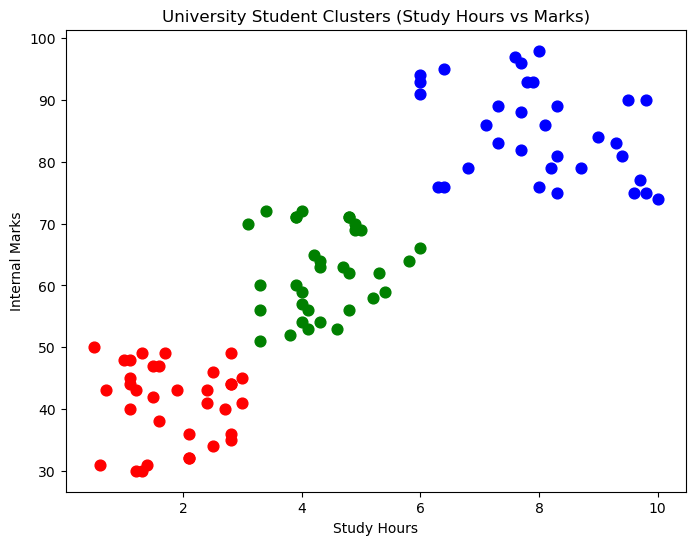

In [18]:
colors = ["red", "blue", "green"]
plt.figure(figsize=(8, 6))
for cluster_num in range(3):
    cluster_data = df[df["Cluster"] == cluster_num]
    plt.scatter(
        cluster_data["Study_Hours"],
        cluster_data["Internal_Marks"],
        s=60,
        color=colors[cluster_num],
        label=f"Cluster {cluster_num}"
    )

plt.xlabel("Study Hours")
plt.ylabel("Internal Marks")
plt.title("University Student Clusters (Study Hours vs Marks)")